# Resource Estimation of Hamiltonian Simulation of the SYK Model

/tmp/ipykernel_19771/2696338188.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


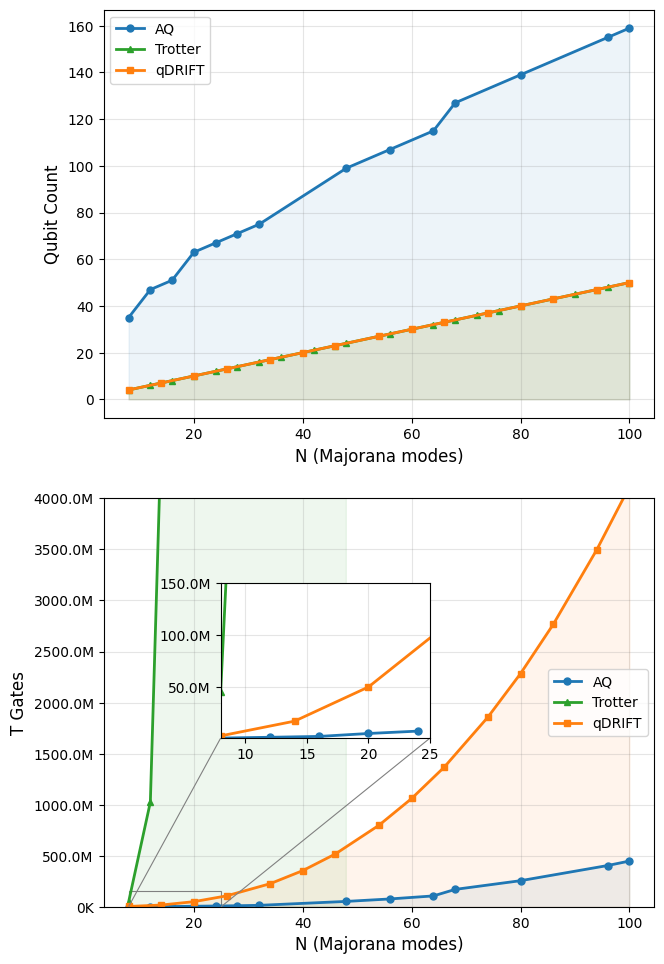

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

export_image_filename = "re_data/N_scaling.pdf"


plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

df = pd.read_csv("re_data/scale_N_J1_order1.csv")
df = df[df["N"] <= 100]
colors  = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])
markers = cycle(["o", "s", "^", "D", "v", "P", "X", "*", "h", "+"])

type_styles = {
    type_label: {"color": next(colors), "marker": next(markers)}
    for type_label in df["type"].unique()
}

fig, axes = plt.subplots(2, 1, figsize=(7, 10))

rotation_eps = 1e-3

inset_data = {}
for (type_label, epsilon), group in df.groupby(["type", "epsilon"]):
    if epsilon == 0.001:
        continue
    group = group.sort_values("epsilon")
    epsilon_alg = group["epsilon"].values[0]
    style = type_styles[type_label]
    group = group.sort_values("N")
    N_vals          = group["N"].tolist()
    qubit_highwater = group["qubit_highwater"].tolist()
    total_t_gates   = (group["t_gates"]+group['rotations']*(0.53* np.log2(1/(1 - (1-group['epsilon'])**(1/ group['rotations']))) + 4.86)).tolist()

    kwargs = dict(color=style["color"], marker=style["marker"],
                  linewidth=2, markersize=5, label=type_label)

    axes[0].plot(N_vals, qubit_highwater, **kwargs)
    axes[0].fill_between(N_vals, qubit_highwater, alpha=0.08, color=style["color"])

    axes[1].plot(N_vals, total_t_gates, **kwargs)
    axes[1].fill_between(N_vals, total_t_gates, alpha=0.08, color=style["color"])
    inset_data[type_label] = {"N": N_vals, "tgates": total_t_gates, "style": style}


axes[0].set_xlabel("N (Majorana modes)", fontsize=12)
axes[0].set_ylabel("Qubit Count", fontsize=12)
axes[0].legend()
axes[0].grid(True, color="gray", alpha=0.2)
axes[1].set_xlabel("N (Majorana modes)", fontsize=12)
axes[1].set_ylabel("T Gates", fontsize=12)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
axes[1].set_ylim(0, 4000000000)
axes[1].legend()
axes[1].grid(True, color="gray", alpha=0.2)

# --- Inset ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

n_zoom = 5  # how many data points to show in inset

axins = inset_axes(axes[1], width="38%", height="38%", loc="upper left",
                   bbox_to_anchor=(0.2, -0.19, 1, 1),
                   bbox_transform=axes[1].transAxes)

all_y = []
for type_label, d in inset_data.items():
    style = d["style"]
    axins.plot(d["N"][:n_zoom], d["tgates"][:n_zoom],
               color=style["color"], marker=style["marker"],
               linewidth=2, markersize=5)
    all_y.extend(d["tgates"][:n_zoom])

# Set zoom window
x1 = min(d["N"][0] for d in inset_data.values())
x2 = max(d["N"][n_zoom - 1] for d in inset_data.values())
y1 = min(all_y) * 0.9
y2 = max(all_y) * 1.1

axins.set_xlim(x1, 25)
axins.set_ylim(y1, 150000000)
axins.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
axins.tick_params(labelsize=10)
axins.grid(True, color="gray", alpha=0.2)

mark_inset(axes[1], axins, loc1=3, loc2=4, fc="none", ec="0.5", lw=0.8)

plt.tight_layout(pad=2.0)
plt.show()
fig.savefig(export_image_filename, dpi=300, bbox_inches="tight")

<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:66: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:66: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_856971/1977243819.py:64: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("$\epsilon_{alg}$", fontsize=12)
/tmp/ipykernel_856971/1977243819.py:66: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title("T Gates vs $\epsilon_{alg}$", fontsize=13)


N: 16
1e-12, inf
1e-11, 3721730.7
1e-10, 3474335.2745164996
1e-09, 3161058.910716947
1e-08, 2859499.1303750803
1e-07, 2572179.174860061
1e-06, 2299440.023859832
1e-05, 2041299.7203456555
0.0001, 1797760.9440501286
0.001, 1568811.1078908343
N: 32
1e-12, inf
1e-11, inf
1e-10, 21148615.400000002
1e-09, 19885215.206693385
1e-08, 18517314.574085634
1e-07, 17082205.69232022
1e-06, 15783704.732630042
1e-05, 14434117.967839215
0.0001, 13129870.10821228
0.001, 11870815.742784832
N: 64
1e-12, inf
1e-11, inf
1e-10, inf
1e-09, 144511745.24
1e-08, 135914606.30371815
1e-07, 127749686.21129629
1e-06, 119638695.8811991
1e-05, 111619303.30875467
0.0001, 103575241.3252275
0.001, 95530606.7068873
N: 100
1e-12, inf
1e-11, inf
1e-10, inf
1e-09, 572741283.5
1e-08, 550359882.2588023
1e-07, 522684491.0196477
1e-06, 493876874.2385344
1e-05, 465128182.8534501
0.0001, 436366359.6702017
0.001, 407598353.1017018
N: 16
1e-12, inf
1e-11, inf
1e-10, inf
1e-09, inf
1e-08, inf
1e-07, 17819592407.02
1e-06, 1596755188.26

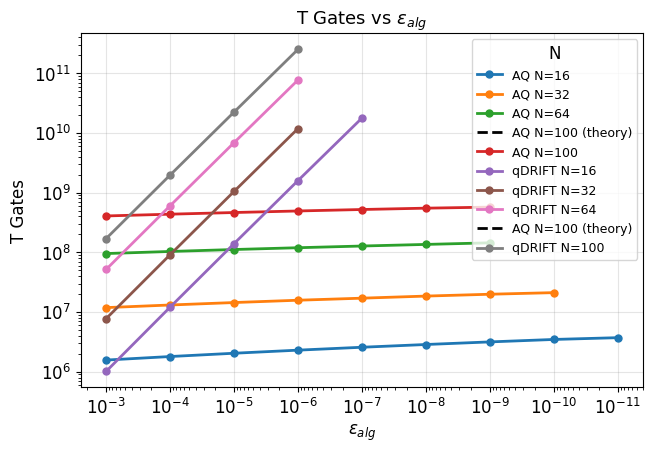

In [ ]:
export_image_filename = "re_data/epsilon_scaling.pdf"

df = pd.read_csv("re_data/scale_eps_J1_order1.csv")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
})

# fig, axes = plt.subplots(2, 1, figsize=(9, 10))
fig, ax = plt.subplots(figsize=(7, 5)) 


# colors = {8: "#378ADD", 16: "#D85A30", 32: "#1D9E75", 64: "#7F77DD", }

for (type_label, N), group in df.groupby(["type", "N"]):
    if N in [8,24,36]:
        continue
    group = group.sort_values("epsilon")
    # color = colors[N]

    # axes[0].plot(group["epsilon"], group["qubit_highwater"], #color=color,
    #              marker="o", linewidth=2, markersize=5, label=f"{group['type'].values[0]} N={N}")
    
    total_t_gates   = (group["t_gates"]+group['rotations']*(0.53* np.log2(1/(1 - (1-group['epsilon'])**(1/ group['rotations']))) + 4.86))

    if N == 100:
        if type_label == 'AQ':
            ax.plot(group["epsilon"], total_t_gates.tolist()[0]+np.log2(1/group["epsilon"]), linestyle="--", marker="D", linewidth=2, color="black", label="AQ N=100 (theory)")
        else:
            ax.plot(group["epsilon"], total_t_gates.tolist()[0]+1/group["epsilon"], linestyle="--", marker="d", linewidth=2, color="black", label="aDRIFT N=100 (theory)")
    
    
    # axes[1].plot(group["epsilon"], total_t_gates,# color=color,
    ax.plot(group["epsilon"], total_t_gates,# color=color,
                 marker="o", linewidth=2, markersize=5, label=f"{group['type'].values[0]} N={N}")

# ax.plot(group["epsilon"], np.log2(1/group["epsilon"]), marker="d", linewidth=2, markersize=5, label="1/epsilon")
# --- Qubit highwater ---
# axes[0].set_xscale("log")
# axes[0].invert_xaxis()
# axes[0].set_xlabel("Epsilon", fontsize=12)
# axes[0].set_ylabel("Qubit highwater", fontsize=12)
# axes[0].set_title("Qubit highwater vs Epsilon", fontsize=13)
# axes[0].legend(title="N")
# axes[0].grid(True, color="gray", alpha=0.2)

# --- Total T-gates ---
# axes[1].set_xscale("log")
# axes[1].set_yscale("log")
# axes[1].invert_xaxis()
# axes[1].set_xlabel("$\epsilon_{alg}$", fontsize=12)
# axes[1].set_ylabel("Total T-gates", fontsize=12)
# axes[1].set_title("Total T Gates vs $\epsilon_{alg}$", fontsize=13)
# axes[1].legend(title="N")
# axes[1].grid(True, color="gray", alpha=0.2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("$\epsilon_{alg}$", fontsize=12)
ax.set_ylabel("T Gates", fontsize=12)
ax.set_title("T Gates vs $\epsilon_{alg}$", fontsize=13)
ax.legend(title="N")
ax.grid(True, color="gray", alpha=0.2)

plt.tight_layout(pad=2.0)
plt.show()
fig.savefig(export_image_filename, dpi=300, bbox_inches="tight")